# Task 1 — Reproducible setup (Spark + folders)

In [1]:
import os
import sys
from pathlib import Path
from pyspark.sql import functions as F
from pyspark.context import SparkContext
from pyspark.sql import SparkSession

# 1) Paths and Configs
MY_ID = "Nate"
OUTPUT_ROOT = Path.home() / "opendota_processed" / MY_ID
DATA_DIR = OUTPUT_ROOT / "data"
FIGURES_DIR = OUTPUT_ROOT / "figures"
SPARK_LOCAL_DIR = OUTPUT_ROOT / "spark_local"

# Create required folder structure
for p in [DATA_DIR, FIGURES_DIR, SPARK_LOCAL_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# 2) Hard reset PySpark globals (stability fix for local machines)
try:
    if 'spark' in globals(): spark.stop()
    for k in ["PYSPARK_GATEWAY_PORT", "PYSPARK_GATEWAY_SECRET"]:
        os.environ.pop(k, None)
    SparkContext._active_spark_context = None
    SparkContext._gateway = None
    SparkContext._jvm = None
    SparkSession._instantiatedContext = None
    SparkSession._activeSession = None
    SparkSession._defaultSession = None
    print("PySpark internals reset")
except Exception:
    pass

# 3) Start Spark (using stable settings from your reference)
spark = (
    SparkSession.builder
    .appName(f"OpenDota_Preprocessing_{MY_ID}")
    .master("local[4]") 
    .config("spark.ui.enabled", "true")
    .config("spark.local.dir", str(SPARK_LOCAL_DIR))
    .config("spark.sql.shuffle.partitions", "32")
    .config("spark.sql.adaptive.enabled", "false")
    .config("spark.sql.autoBroadcastJoinThreshold", "-1")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")
print(f"Spark started: {spark.version}")
print(f" - Master: {spark.sparkContext.master}")
print(f" - Spark UI: {spark.sparkContext.uiWebUrl}")

PySpark internals reset
Spark started: 3.5.8
 - Master: local[4]
 - Spark UI: http://bb-8.local:4040


# Task 2 — Splitting the “large” CSV

![Task 2 Bash Evidence](task2.png)



# Task 3 — Scalable ingestion in Spark (DataFrame-only)

In [3]:
# Path to the 100k-line shards created in the Bash step
SAMPLE_CSV = Path.home() / "opendota_processed" / MY_ID / "matches_parts" / "part-*.csv"

# Reading using Column Projection and no schema inference
matches_raw = (spark.read
               .option("header", "true")
               .option("inferSchema", "false") 
               .csv(str(SAMPLE_CSV))
               .select("match_id", "start_time", "duration", "radiant_win", "cluster", "game_mode", "lobby_type")
              )

# Preview required for Task 3
matches_raw.limit(5).show()
print(f"Total records ingested: {matches_raw.count():,}")

+---------+----------+--------+-----------+-------+---------+----------+
| match_id|start_time|duration|radiant_win|cluster|game_mode|lobby_type|
+---------+----------+--------+-----------+-------+---------+----------+
|473260719|1390019262|    3234|          t|    114|        1|         0|
|473260722|1390019274|    2360|          f|    152|        1|         0|
|473260723|1390019260|    2546|          f|    124|        1|         0|
|473260724|1390019278|    2647|          f|    204|        1|         0|
|473260725|1390019250|    3030|          t|    123|        1|         7|
+---------+----------+--------+-----------+-------+---------+----------+

Total records ingested: 500,000


# Task 4 — Data Cleaning (Spark)

In [4]:
before_count = matches_raw.count()

# Constructing clean match data with specific casting and filtering
matches_clean = (
    matches_raw
    .withColumn("match_id", F.expr("try_cast(match_id as long)"))
    .withColumn("start_time", F.expr("try_cast(start_time as long)"))
    .withColumn("duration", F.expr("try_cast(duration as int)"))
    .withColumn("radiant_win", F.col("radiant_win") == "t")
    .dropna(subset=["match_id"])
    .dropDuplicates(["match_id"])
)

# Filtering unreasonable durations (5m to 3h)
lower_bound, upper_bound = 300, 10800
matches_clean = matches_clean.filter(
    (F.col("duration") >= lower_bound) & (F.col("duration") <= upper_bound)
)

after_count = matches_clean.count()

print(f"Done Cleaning")
print(f"Before count: {before_count:,}")
print(f"After count:  {after_count:,}")

# Null-rate summary for evidence
matches_clean.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in matches_clean.columns
]).show()

Done Cleaning
Before count: 500,000
After count:  497,320
+--------+----------+--------+-----------+-------+---------+----------+
|match_id|start_time|duration|radiant_win|cluster|game_mode|lobby_type|
+--------+----------+--------+-----------+-------+---------+----------+
|       0|         0|       0|          1|      0|        0|         0|
+--------+----------+--------+-----------+-------+---------+----------+



# Task 5 — Data Transformation (Spark)

In [5]:
matches_features = (
    matches_clean
    .withColumn("start_ts", F.from_unixtime("start_time").cast("timestamp"))
    .withColumn("year", F.year("start_ts"))
    .withColumn("month", F.month("start_ts"))
    .withColumn("duration_min", F.col("duration") / 60)
    .withColumn("duration_bin",
        F.when(F.col("duration_min") < 20, "Short (<20m)")
         .when((F.col("duration_min") >= 20) & (F.col("duration_min") < 30), "Standard (20-30m)")
         .when((F.col("duration_min") >= 30) & (F.col("duration_min") < 45), "Average (30-45m)")
         .when((F.col("duration_min") >= 45) & (F.col("duration_min") < 60), "Long (45-60m)")
         .otherwise("Ultra Long (>60m)")
    )
)

print("Done Task 5")
matches_features.select("match_id", "start_ts", "year", "month", "duration_min", "duration_bin").show(5)

Done Task 5
+----------+-------------------+----+-----+------------------+----------------+
|  match_id|           start_ts|year|month|      duration_min|    duration_bin|
+----------+-------------------+----+-----+------------------+----------------+
| 473260800|2014-01-18 12:35:08|2014|    1|30.716666666666665|Average (30-45m)|
|1009842190|2014-11-07 20:14:37|2014|   11|49.166666666666664|   Long (45-60m)|
|1808667856|2015-09-21 09:10:52|2015|    9|              51.6|   Long (45-60m)|
| 692810562|2014-06-01 10:31:19|2014|    6| 35.68333333333333|Average (30-45m)|
|1980325600|2015-12-05 13:58:47|2015|   12|35.666666666666664|Average (30-45m)|
+----------+-------------------+----+-----+------------------+----------------+
only showing top 5 rows



# Task 6 — Data Reduction (Partitioned Parquet)

In [6]:
PARQUET_OUT = str(DATA_DIR / "matches_parquet")

# Writing to Parquet using partitions
(matches_features.write
    .mode("overwrite")
    .partitionBy("year", "month")
    .parquet(PARQUET_OUT))

print(f"✅ Data written to: {PARQUET_OUT}")

# Evidence of PartitionFilters (Required for report)
df_final = spark.read.parquet(PARQUET_OUT)
print("\nExecution Plan for Partition Filter Evidence:")
df_final.filter((F.col("year") == 2015) & (F.col("month") == 12)).explain(True)

✅ Data written to: C:\Users\ACER\opendota_processed\Nate\data\matches_parquet

Execution Plan for Partition Filter Evidence:
== Parsed Logical Plan ==
'Filter (('year = 2015) AND ('month = 12))
+- Relation [match_id#615L,start_time#616L,duration#617,radiant_win#618,cluster#619,game_mode#620,lobby_type#621,start_ts#622,duration_min#623,duration_bin#624,year#625,month#626] parquet

== Analyzed Logical Plan ==
match_id: bigint, start_time: bigint, duration: int, radiant_win: boolean, cluster: string, game_mode: string, lobby_type: string, start_ts: timestamp, duration_min: double, duration_bin: string, year: int, month: int
Filter ((year#625 = 2015) AND (month#626 = 12))
+- Relation [match_id#615L,start_time#616L,duration#617,radiant_win#618,cluster#619,game_mode#620,lobby_type#621,start_ts#622,duration_min#623,duration_bin#624,year#625,month#626] parquet

== Optimized Logical Plan ==
Filter ((isnotnull(year#625) AND isnotnull(month#626)) AND ((year#625 = 2015) AND (month#626 = 12)))
+- R

# Task 7 — EDA (aggregate-first; do not load everything)

In [10]:
# Match Activity over time
activity_trend = matches_features.groupBy("year", "month").count().orderBy("year", "month")

# Average Duration Trend
duration_trend = matches_features.groupBy("year", "month").agg(F.avg("duration_min").alias("avg_dur_min")).orderBy("year", "month")

# Duration Distribution
dist_counts = matches_features.groupBy("duration_bin").count().orderBy("count", ascending=False)

# Radiant Win Rate Stability
win_rate_trend = matches_features.groupBy("year").agg(
    F.avg(F.col("radiant_win").cast("int")).alias("radiant_win_rate")
).orderBy("year")

# Lobby Type Distribution
lobby_dist = matches_features.groupBy("lobby_type").count().orderBy("count", ascending=False)

# Top 10 Busiest Clusters (Regions)
cluster_activity = matches_features.groupBy("cluster").count().orderBy("count", ascending=False).limit(10)

print("Aggregations complete. Results ready for Task 8.")
activity_trend.show(5)

Aggregations complete. Results ready for Task 8.
+----+-----+-----+
|year|month|count|
+----+-----+-----+
|2011|    7|    7|
|2011|    9|    2|
|2011|   10|   19|
|2011|   11|   34|
|2011|   12|   96|
+----+-----+-----+
only showing top 5 rows



# Task 8 — Visualization (static + interactive)

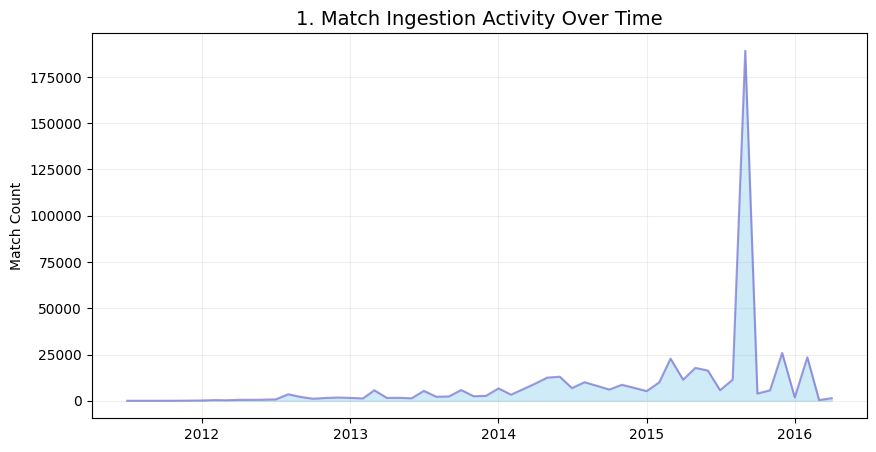

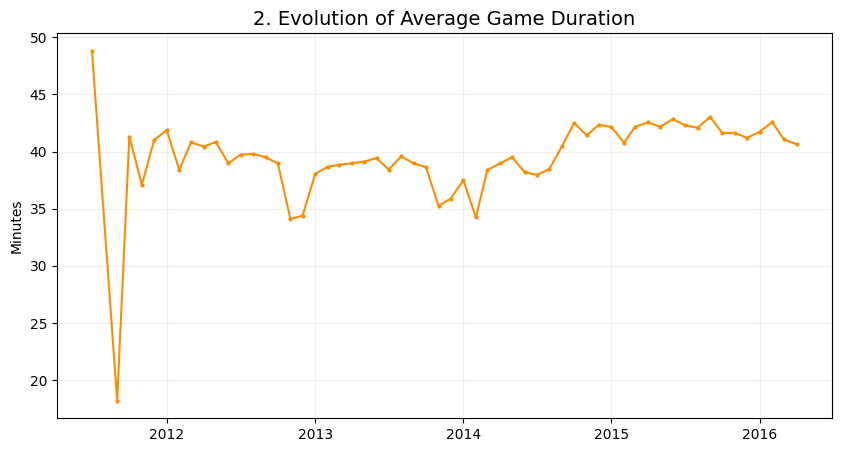

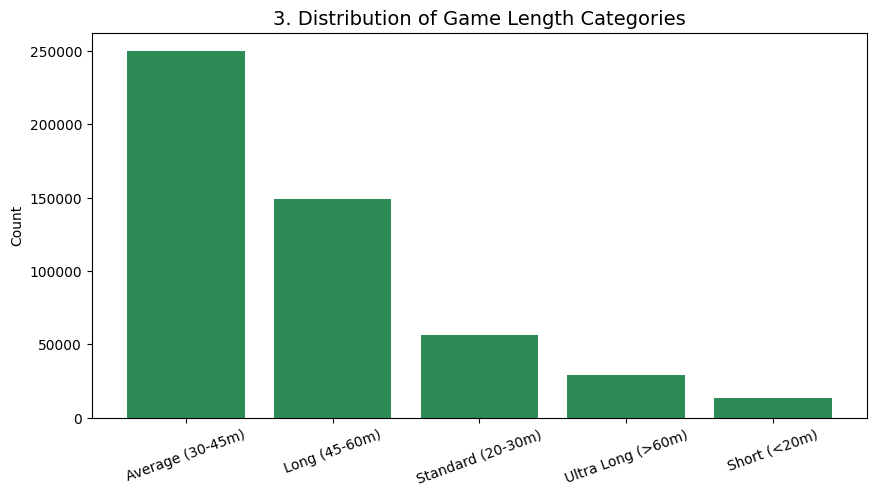

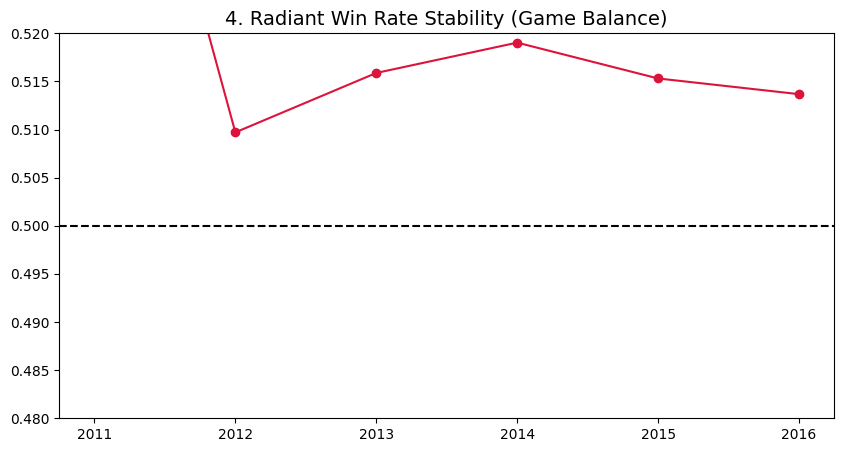

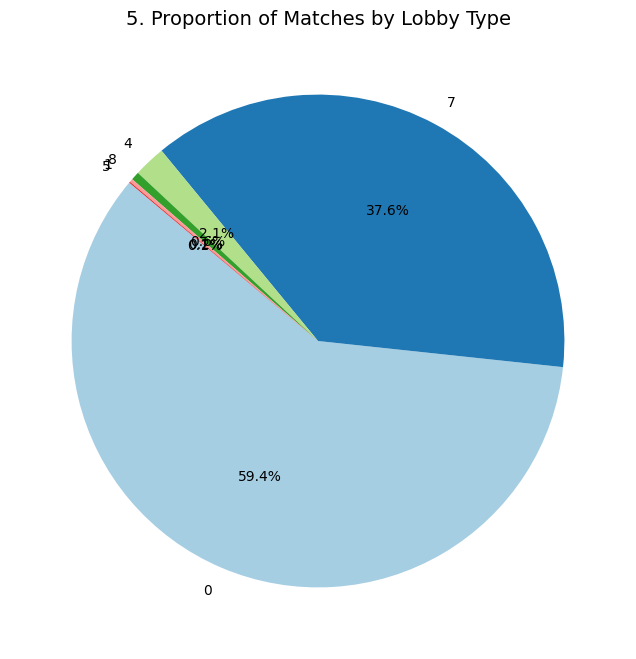

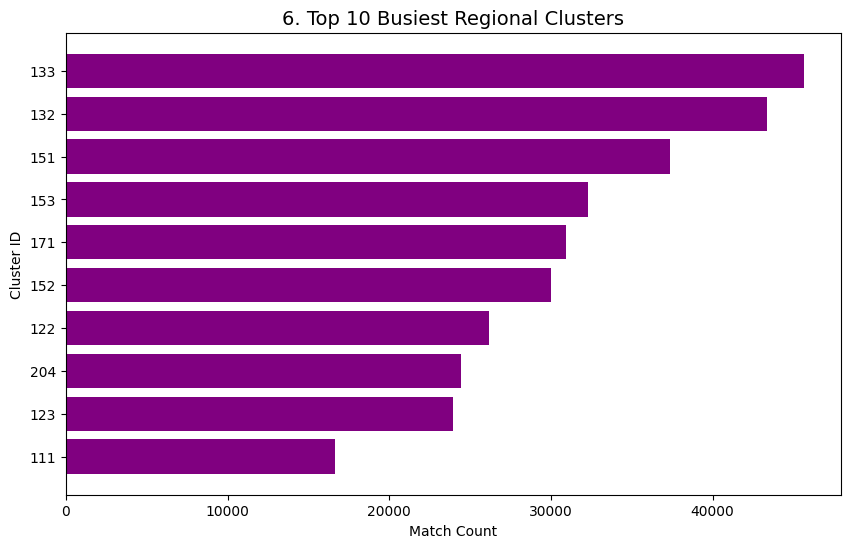

In [12]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns # Optional: if you have seaborn, it makes bar charts prettier

# Convert Spark to Pandas
pdf_act = activity_trend.toPandas()
pdf_dur_trend = duration_trend.toPandas()
pdf_dist = dist_counts.toPandas()
pdf_win = win_rate_trend.toPandas()
pdf_lobby = lobby_dist.toPandas()
pdf_cluster = cluster_activity.toPandas()

# Sort Date for time-series
for df in [pdf_act, pdf_dur_trend]:
    df['date'] = pd.to_datetime(df['year'].astype(str) + '-' + df['month'].astype(str) + '-01')
    df.sort_values('date', inplace=True)

# Set a style
plt.style.use('seaborn-v0_8-muted') # Standard clean style

# Chart 1: Match Activity (Time Series)
plt.figure(figsize=(10, 5))
plt.fill_between(pdf_act['date'], pdf_act['count'], color="skyblue", alpha=0.4)
plt.plot(pdf_act['date'], pdf_act['count'], color="Slateblue", alpha=0.6)
plt.title("1. Match Ingestion Activity Over Time", fontsize=14)
plt.ylabel("Match Count")
plt.grid(True, alpha=0.2)
plt.savefig(FIGURES_DIR / "1_activity.png")
plt.show()

# Chart 2: Average Duration (Time Series) 
plt.figure(figsize=(10, 5))
plt.plot(pdf_dur_trend['date'], pdf_dur_trend['avg_dur_min'], color="darkorange", marker='.', markersize=4)
plt.title("2. Evolution of Average Game Duration", fontsize=14)
plt.ylabel("Minutes")
plt.grid(True, alpha=0.2)
plt.savefig(FIGURES_DIR / "2_duration_trend.png")
plt.show()

# Chart 3: Duration Bins (Bar Chart) 
plt.figure(figsize=(10, 5))
plt.bar(pdf_dist['duration_bin'], pdf_dist['count'], color="seagreen")
plt.title("3. Distribution of Game Length Categories", fontsize=14)
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.savefig(FIGURES_DIR / "3_duration_bins.png")
plt.show()

# Chart 4: Win Rate Stability (Stability Chart) 
plt.figure(figsize=(10, 5))
plt.plot(pdf_win['year'].astype(str), pdf_win['radiant_win_rate'], marker='o', color="crimson")
plt.axhline(0.5, color='black', linestyle='--')
plt.title("4. Radiant Win Rate Stability (Game Balance)", fontsize=14)
plt.ylim(0.48, 0.52)
plt.savefig(FIGURES_DIR / "4_win_rate.png")
plt.show()

# Chart 5: Lobby Type Distribution (Pie Chart)
plt.figure(figsize=(8, 8))
plt.pie(pdf_lobby['count'], labels=pdf_lobby['lobby_type'], autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title("5. Proportion of Matches by Lobby Type", fontsize=14)
plt.savefig(FIGURES_DIR / "5_lobby_pie.png")
plt.show()

# Chart 6: Top 10 Busiest Clusters (Horizontal Bar) ---
plt.figure(figsize=(10, 6))
plt.barh(pdf_cluster['cluster'].astype(str), pdf_cluster['count'], color="purple")
plt.gca().invert_yaxis() # Highest count on top
plt.title("6. Top 10 Busiest Regional Clusters", fontsize=14)
plt.xlabel("Match Count")
plt.ylabel("Cluster ID")
plt.savefig(FIGURES_DIR / "6_clusters.png")
plt.show()